# PHYS 771 HW2, James Dufresne, due July 5th 11:59pm


In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from scipy.signal import lombscargle as ls
from tqdm import tqdm
import lightkurve as lk
from wotan import flatten, transit_mask
import batman

# Problem 3

## a) Use lightkurve to search and download the PDCSAP flux for your target/sector (see attached notebook). Remove NaNs. Plot the full light curve. Identify the transits by eye (mark them). Report the literature period, epoch, depth, and duration you're expecting, so you have something to sanity-check against later.

### loading TESS data (copied from example notebook)

Text(0.5, 0, 'Time (BTJD)')

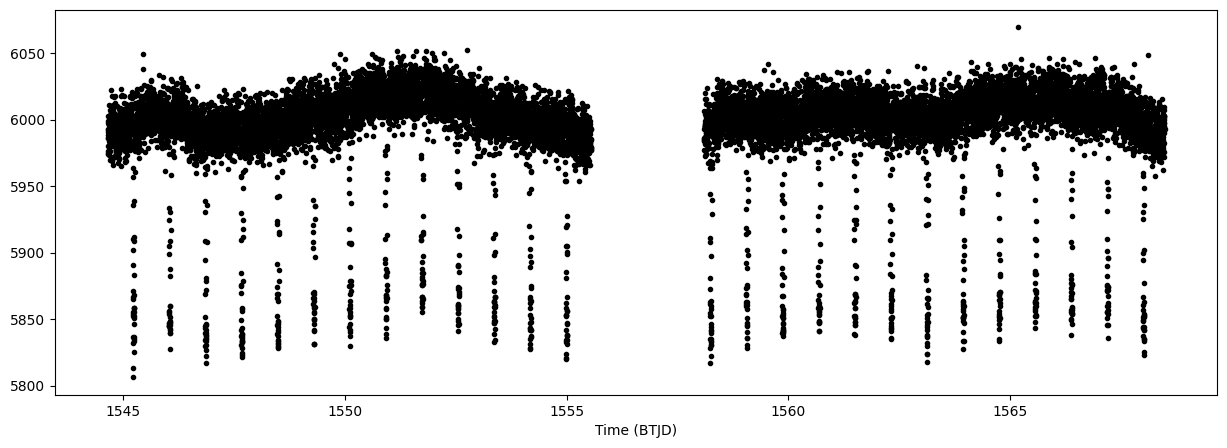

In [2]:
# dataset information
tic = "TIC 36734222" # replace with the actual TIC ID
sector = 9 # March 2019 midpoint

# searching for the desired dataset
sr = lk.search_lightcurve(tic, mission="TESS", sector=sector)
# download the data and storing in variable lc
lc = sr.download()

# removing bad data (NaN values) 
lc = lc.remove_nans()
lc = lc[lc.quality == 0]
lc = lc[~lc.flux.mask]

# extracting time, flux, and exposure time
time = np.asarray(lc.time.value, dtype=float)
flux = np.asarray(lc.flux.value, dtype=float)

# remove any remaining NaNs
mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

plt.figure(figsize=(15,5))
plt.plot(time, flux, "k.")
plt.xlabel("Time (BTJD)")
# plt.axvline(2338.7)
# plt.axvline(2342.1)
# print(2342.1-2338.7)

### Sanity checks and marking transits by eye

Period obtained from marking transits by eye: 0.813 days


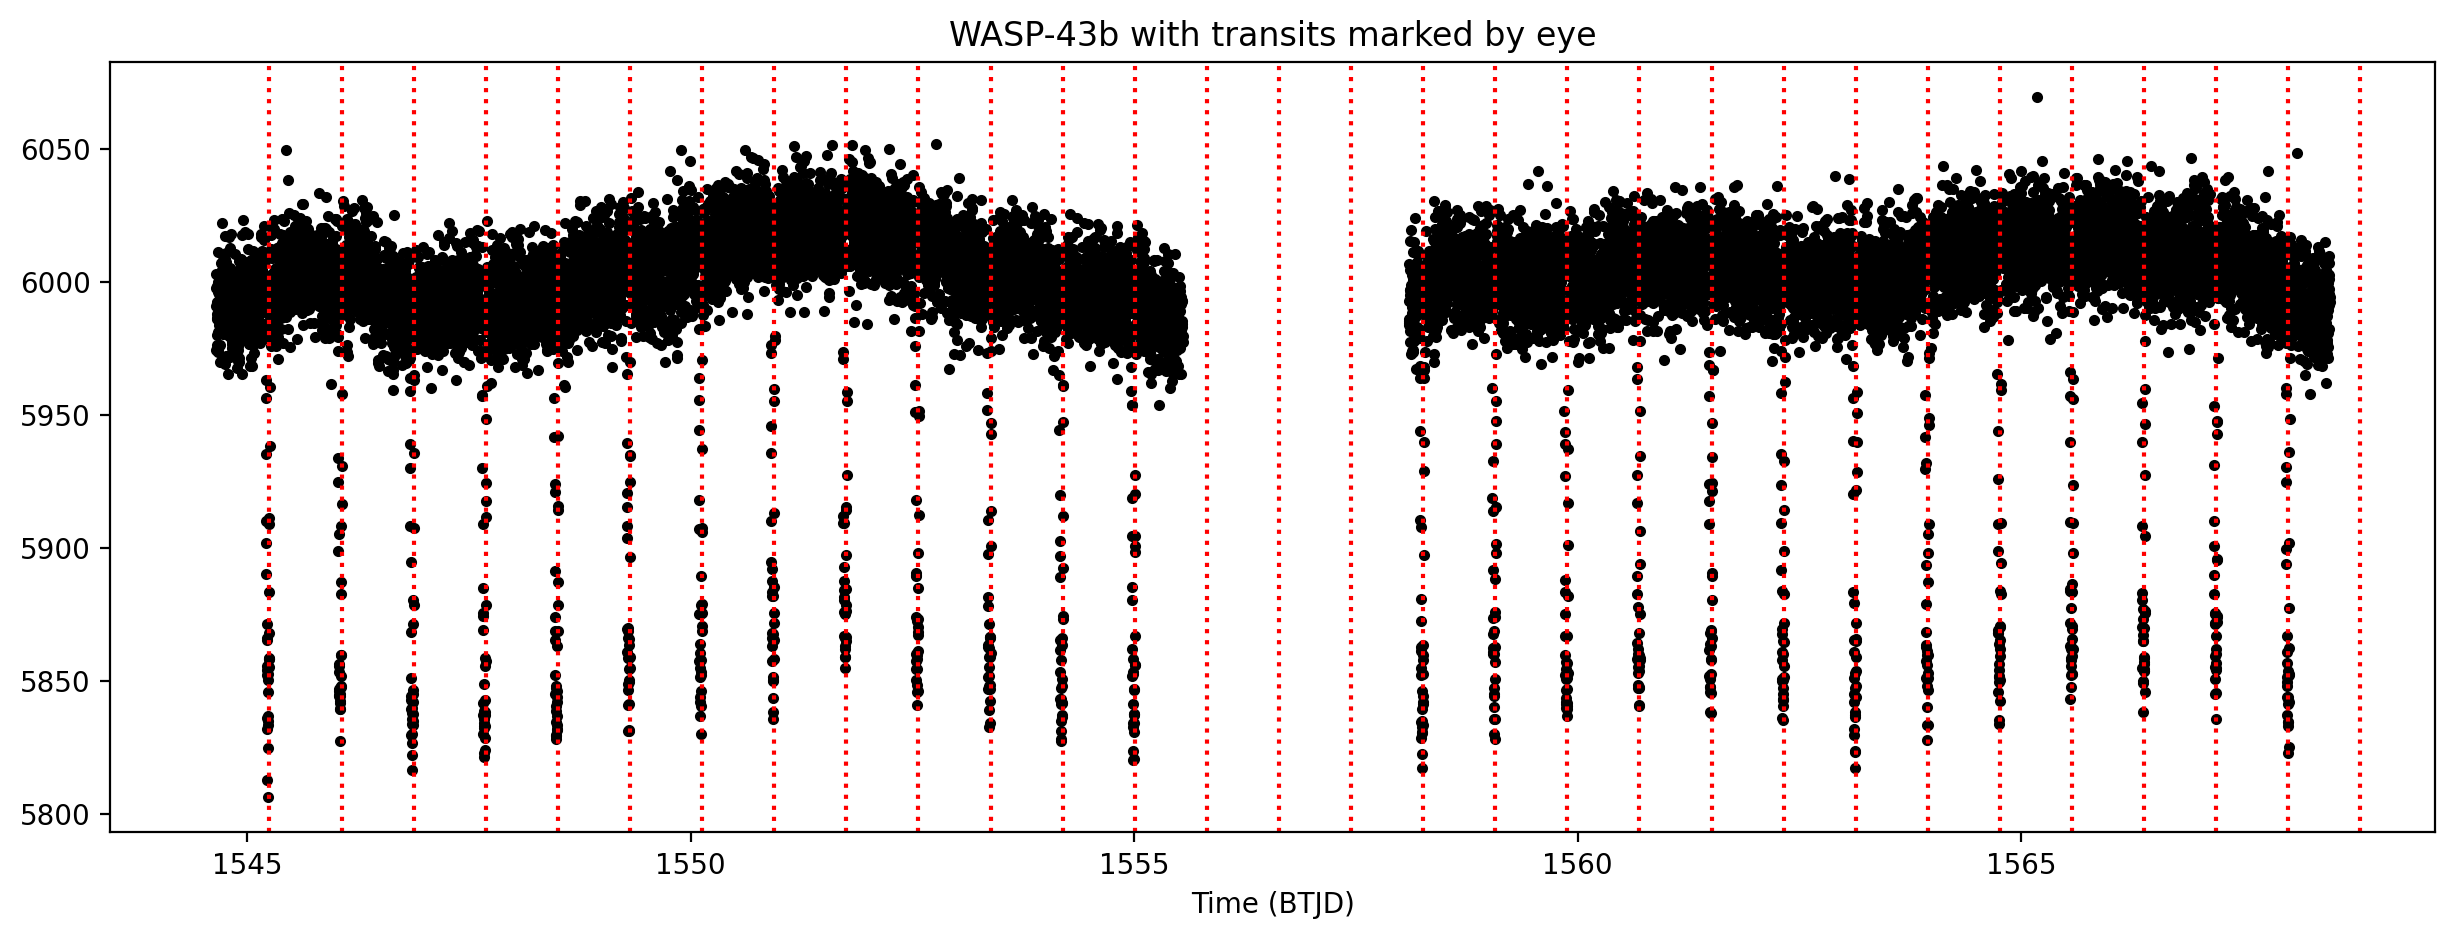

In [3]:
plt.figure(figsize=(15,5), dpi = 200)
plt.plot(time, flux, "k.")
plt.xlabel("Time (BTJD)")
plt.title("WASP-43b with transits marked by eye")

# identify transits by eye
period_by_eye = 0.813 # iterated by eye until match
for i in range(0,30):
    plt.axvline(1545.25+(i*period_by_eye), ls='dotted', c = 'red') # plot a red line at the first transit and every 0.813 days subsequent
print(f"Period obtained from marking transits by eye: {period_by_eye} days")

### Literature values

source: NASA exoplanet archive (https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=TOI)

In [4]:
period_lit = 0.813473271080055 * u.day
dperiod_lit = 0.00000030344734 * u.day

epoch_lit = 2458543.604633  # BJD
depoch_lit = 0.00003116095  # BJD

# BTJD to match our time x-axis units
# Convert BJD to BTJD
epoch_lit_BTJD = 2458543.604633 - 2457000.0  # BTJD
depoch_lit_BTJD = 0.00003116095 # BTJD, uncertainty is not a specific date but a span of time so remains unaffected

duration_lit = 1.26296395605359 * u.hour # hours
dduration_lit = 0.004698167 * u.hour #hours

depth_lit = 25866.834740031 # ppm
ddepth_lit = 86.57887 # ppm

print("\nLiterature values for WASP-43b")
print("-" * 40)
print(f" Period = {period_lit.value:.3e} ± {dperiod_lit:3e}")
print(f" Epoch = {epoch_lit_BTJD:.3e} ± {depoch_lit_BTJD:3e} BTJD")
print(f" Duration = {duration_lit.value:.3e} ± {dduration_lit:3e}")
print(f" Depth = {depth_lit:.3e} ± {ddepth_lit:3e} ppm")



Literature values for WASP-43b
----------------------------------------
 Period = 8.135e-01 ± 3.034473e-07 d
 Epoch = 1.544e+03 ± 3.116095e-05 BTJD
 Duration = 1.263e+00 ± 4.698167e-03 h
 Depth = 2.587e+04 ± 8.657887e+01 ppm


## b) Use wotan.flatten to remove long-term/stellar trends and to normalize your flux, i.e. to rescale your lightcurve in units of stellar flux (approximately). Mask the transits before flattening (or use wotan's transit mask / iterative clipping option), if you flatten through the transit, the detrending will partially fit out the transit itself and bias your depth. Show a plot of the light curve with and without masking to demonstrate you checked this. Justify your choice of window length / method (biweight, gp, etc.) show at least one comparison plot of two window lengths and explain why you picked the one you did. Report the out-of-transit scatter (ppm) before and after flattening.

### i) Investigating the effect of masking out transits

Need to mask out transits first, then flatten with/without for comparison. 

In [5]:
# Masking out transits
transit_mask = transit_mask(
    time, 
    period=period_lit.to(u.day).value, 
    duration=duration_lit.to(u.day).value,
    T0=epoch_lit_BTJD,
)

#### i.i) Masking with default 0.5 days window

<b>Flatten parameters choices justifications for investigating the effect of masking transits:</b>

Window_length: Investigating the effect of masking transits so will keep it at the 0.5 days default value.

Method: Biweight because it's the default option.

In [6]:
# flatten params
window_length = 0.5 # Filter length in units of time (e.g., days)
method = 'biweight' # Detrending algorithm 
return_trend = True # return stellar variation line as well as the flattend lc

# flatten lightcurve without masking
flatten_lc, trend_lc = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method=method,       
    return_trend=return_trend,
)

# flatten lightcurve with masking transits
flatten_lc_masked, trend_lc_masked = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method=method,       
    return_trend=return_trend,
    mask=transit_mask,
)


Comparison between with/without masking transits 

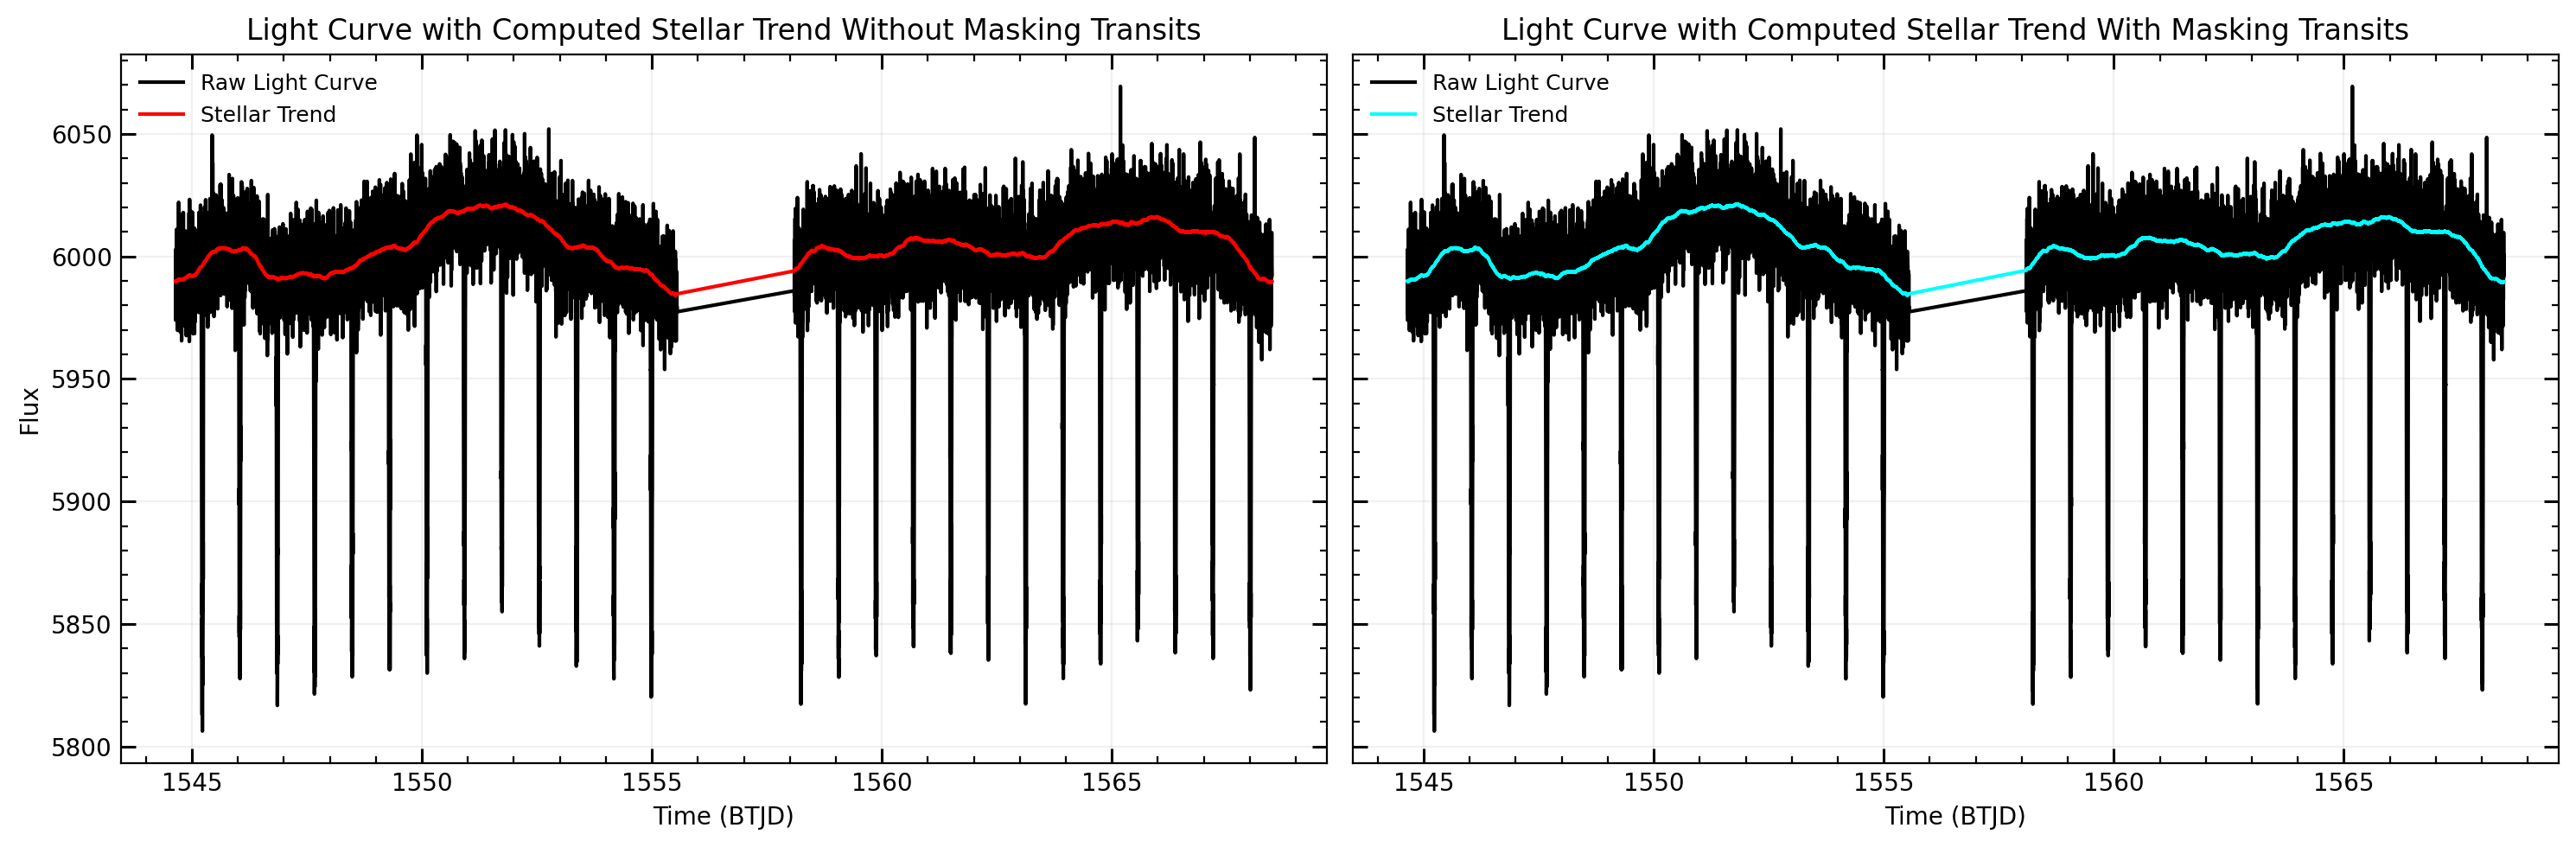

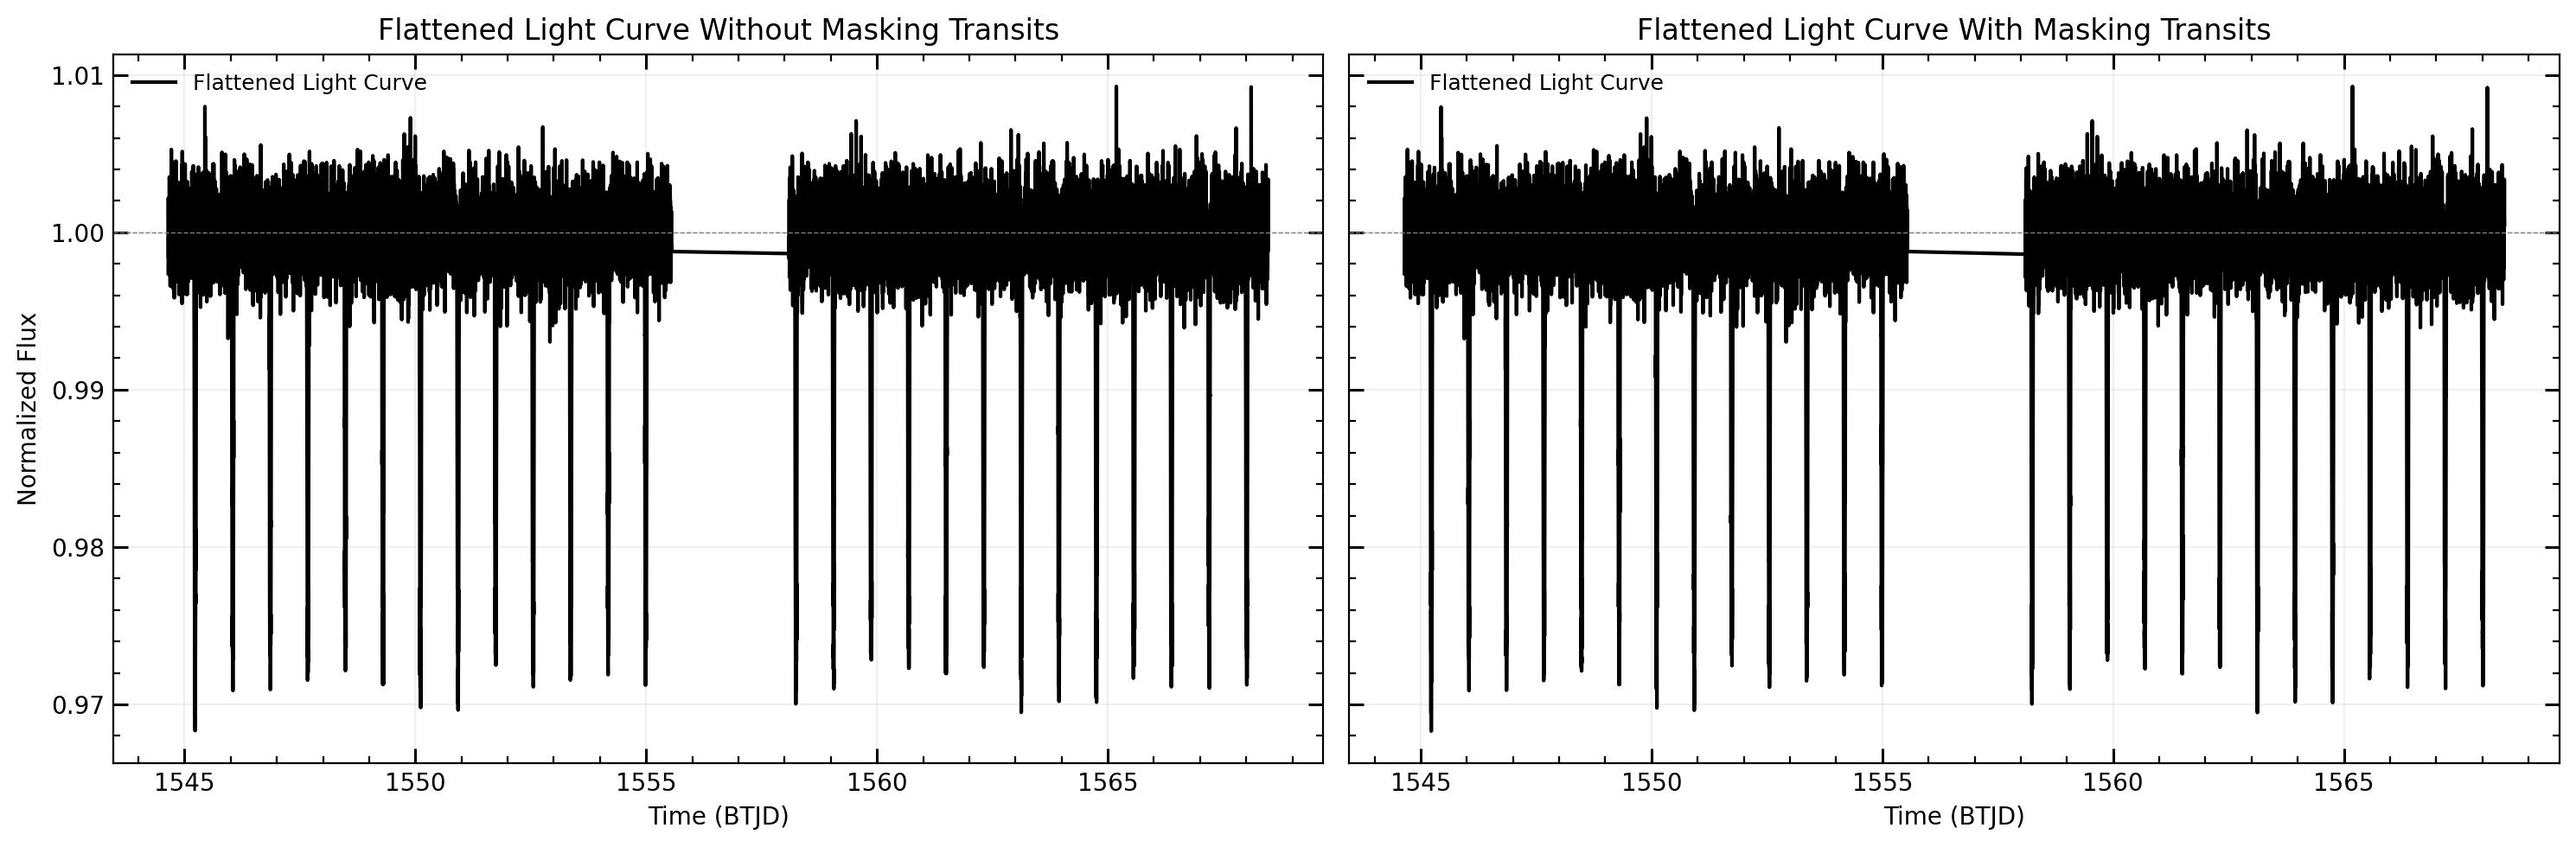

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, dpi=200, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: Raw data with computed stellar trend (No Mask)
ax[0].plot(time, flux, color='black', label = "Raw Light Curve")
ax[0].plot(time, trend_lc, color='red', label = "Stellar Trend")
ax[0].set_title('Light Curve with Computed Stellar Trend Without Masking Transits')
ax[0].set_ylabel('Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Right: Raw data with computed stellar trend (With Mask)
ax[1].plot(time, flux, color='black', label = "Raw Light Curve")
ax[1].plot(time, trend_lc_masked, color='cyan', label = "Stellar Trend")
ax[1].set_title('Light Curve with Computed Stellar Trend With Masking Transits')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="best")

plt.tight_layout()
plt.show()





fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, dpi=200, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: Flattened Result (No Mask)
ax[0].plot(time, flatten_lc, color='black', label = "Flattened Light Curve")
ax[0].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[0].set_title('Flattened Light Curve Without Masking Transits')
ax[0].set_ylabel('Normalized Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Right: Flattened Result (With Mask)
ax[1].plot(time, flatten_lc_masked, color='black', label = "Flattened Light Curve")
ax[1].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[1].set_title('Flattened Light Curve With Masking Transits')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

No visible difference between masking transist and not masking them with a window_length of 0.5 days (about 10 times longer than the transit duration). I believe the difference would be much more pronouced if the window size was smaller than the transit duration and show this below. Thus, masking out transits is important, with the effect particularly pronounced with small window lengths. Since you want the smallest window length possible to best identify the stellar variability trend, masking out transits with a small window size is optimal to remove stellar variability. 

#### i.ii) Masking with a small 1/2 duration window

<b>Flatten parameters choices justifications for investigating the effect of masking transits with a small window length:</b>

Window_length: Make it smaller than a transit duration so the effect of masking is very pronounced. 

Method: Biweight because it's the default option.

In [8]:
# flatten params
window_length = 0.5 * duration_lit.to(u.day).value # Filter length in units of time (e.g., days) 
method = 'biweight' # Detrending algorithm 
return_trend = True # return stellar variation line as well as the flattend lc

# flatten lightcurve without masking
flatten_lc, trend_lc = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method=method,       
    return_trend=return_trend,
)

# flatten lightcurve with masking transits
flatten_lc_masked, trend_lc_masked = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method=method,       
    return_trend=return_trend,
    mask=transit_mask,
)

computing the out of transit scatter before / after flattening

In [9]:
# invert transit mask to get Out of Transit mask
OoT_mask = ~transit_mask 

relative_OoT_flux = flux[OoT_mask] / np.nanmedian(flux[OoT_mask]) # divide by median since that will be the baseline OoT flux, max value is just some noisy outlier way above baseline
pre_scatter = np.nanstd(relative_OoT_flux) * 1e6

# already normalized from flatten so no need to compute relative flux
post_scatter = np.nanstd(flatten_lc_masked[OoT_mask]) * 1e6

print("\nPre/Post Flatten Out-of-Transit Scatter")
print("-" * 40)
print(f" Pre-flattening Scatter= {pre_scatter:.3e} ppm")
print(f" Post-flattening Scatter = {post_scatter:.3e} ppm")


Pre/Post Flatten Out-of-Transit Scatter
----------------------------------------
 Pre-flattening Scatter= 2.317e+03 ppm
 Post-flattening Scatter = 1.763e+03 ppm


The out-of-transit scatter decreased after flattening, indicating that the detrending reduced baseline variability while preserving the transit signal.

plotting

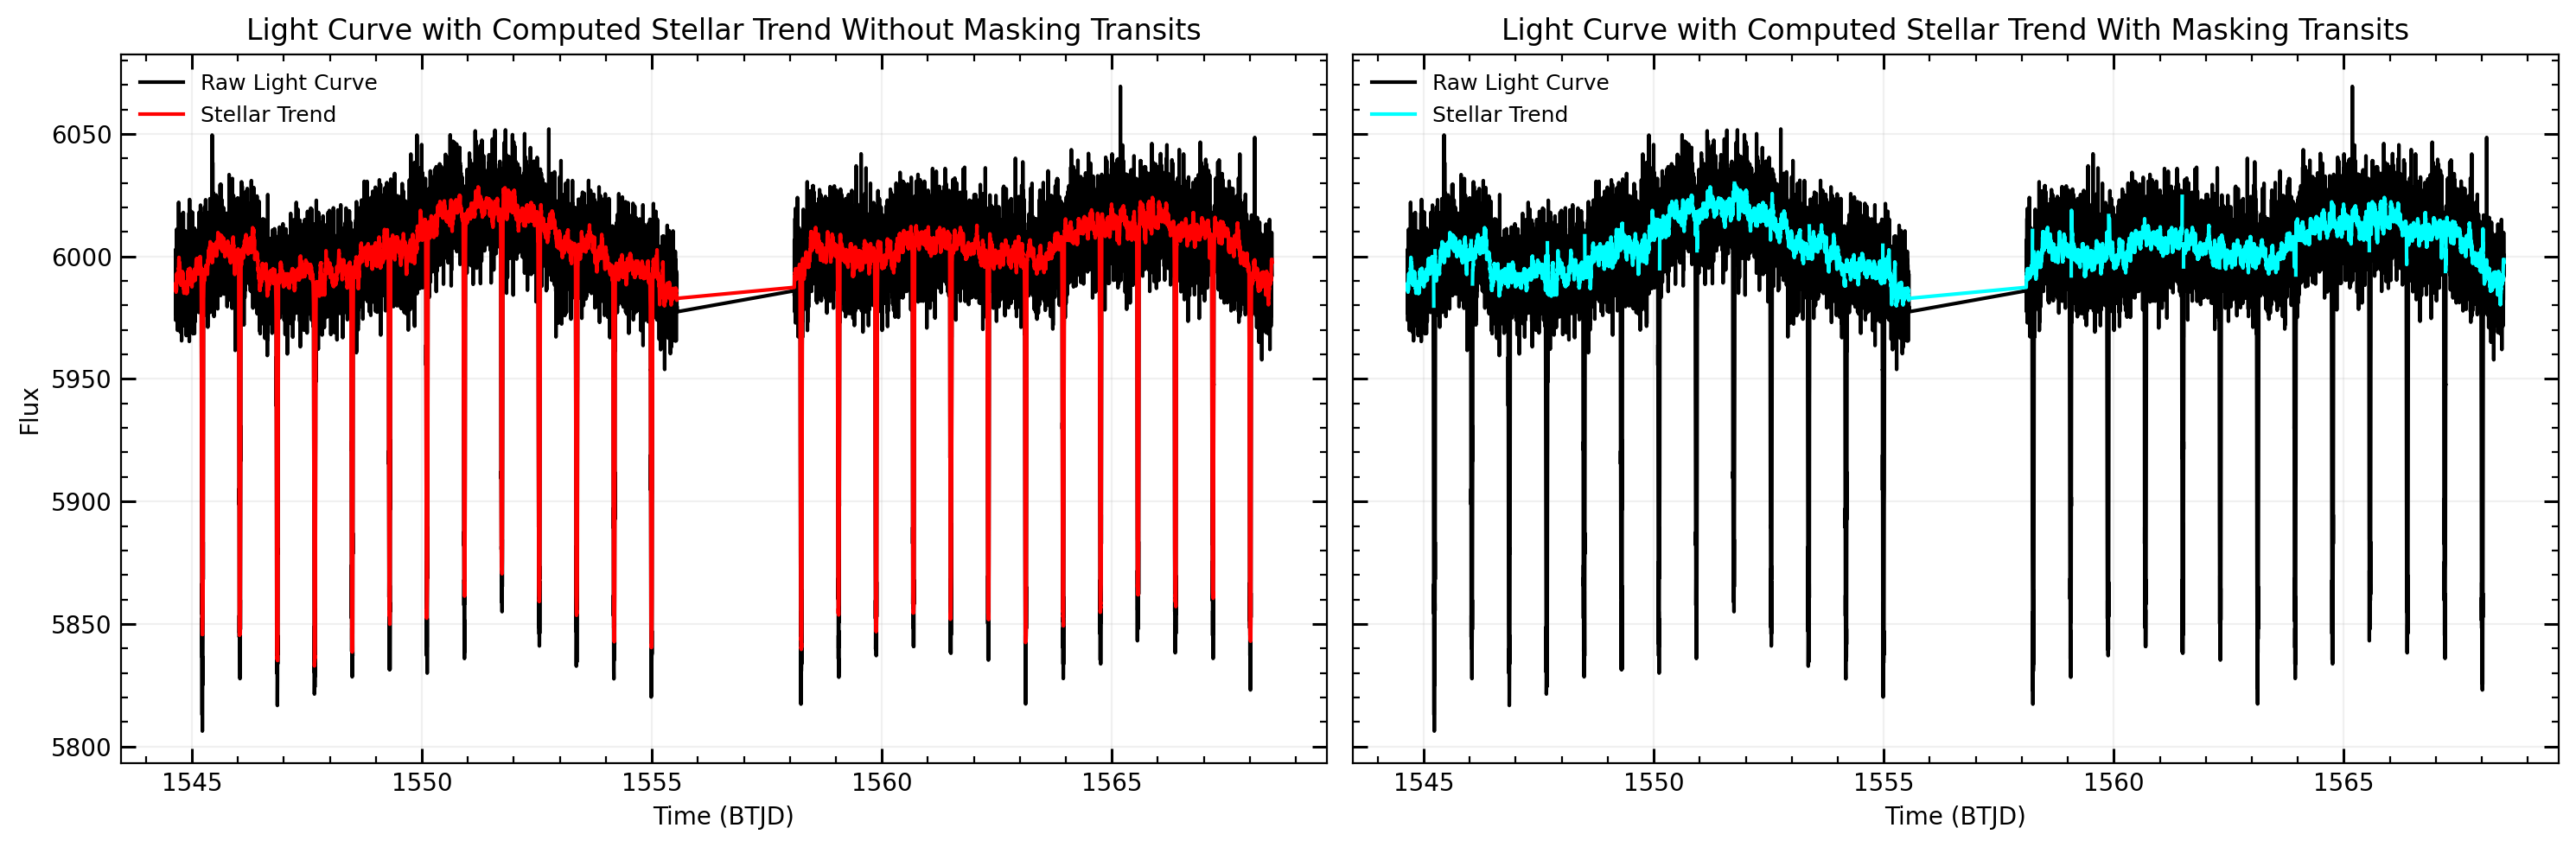

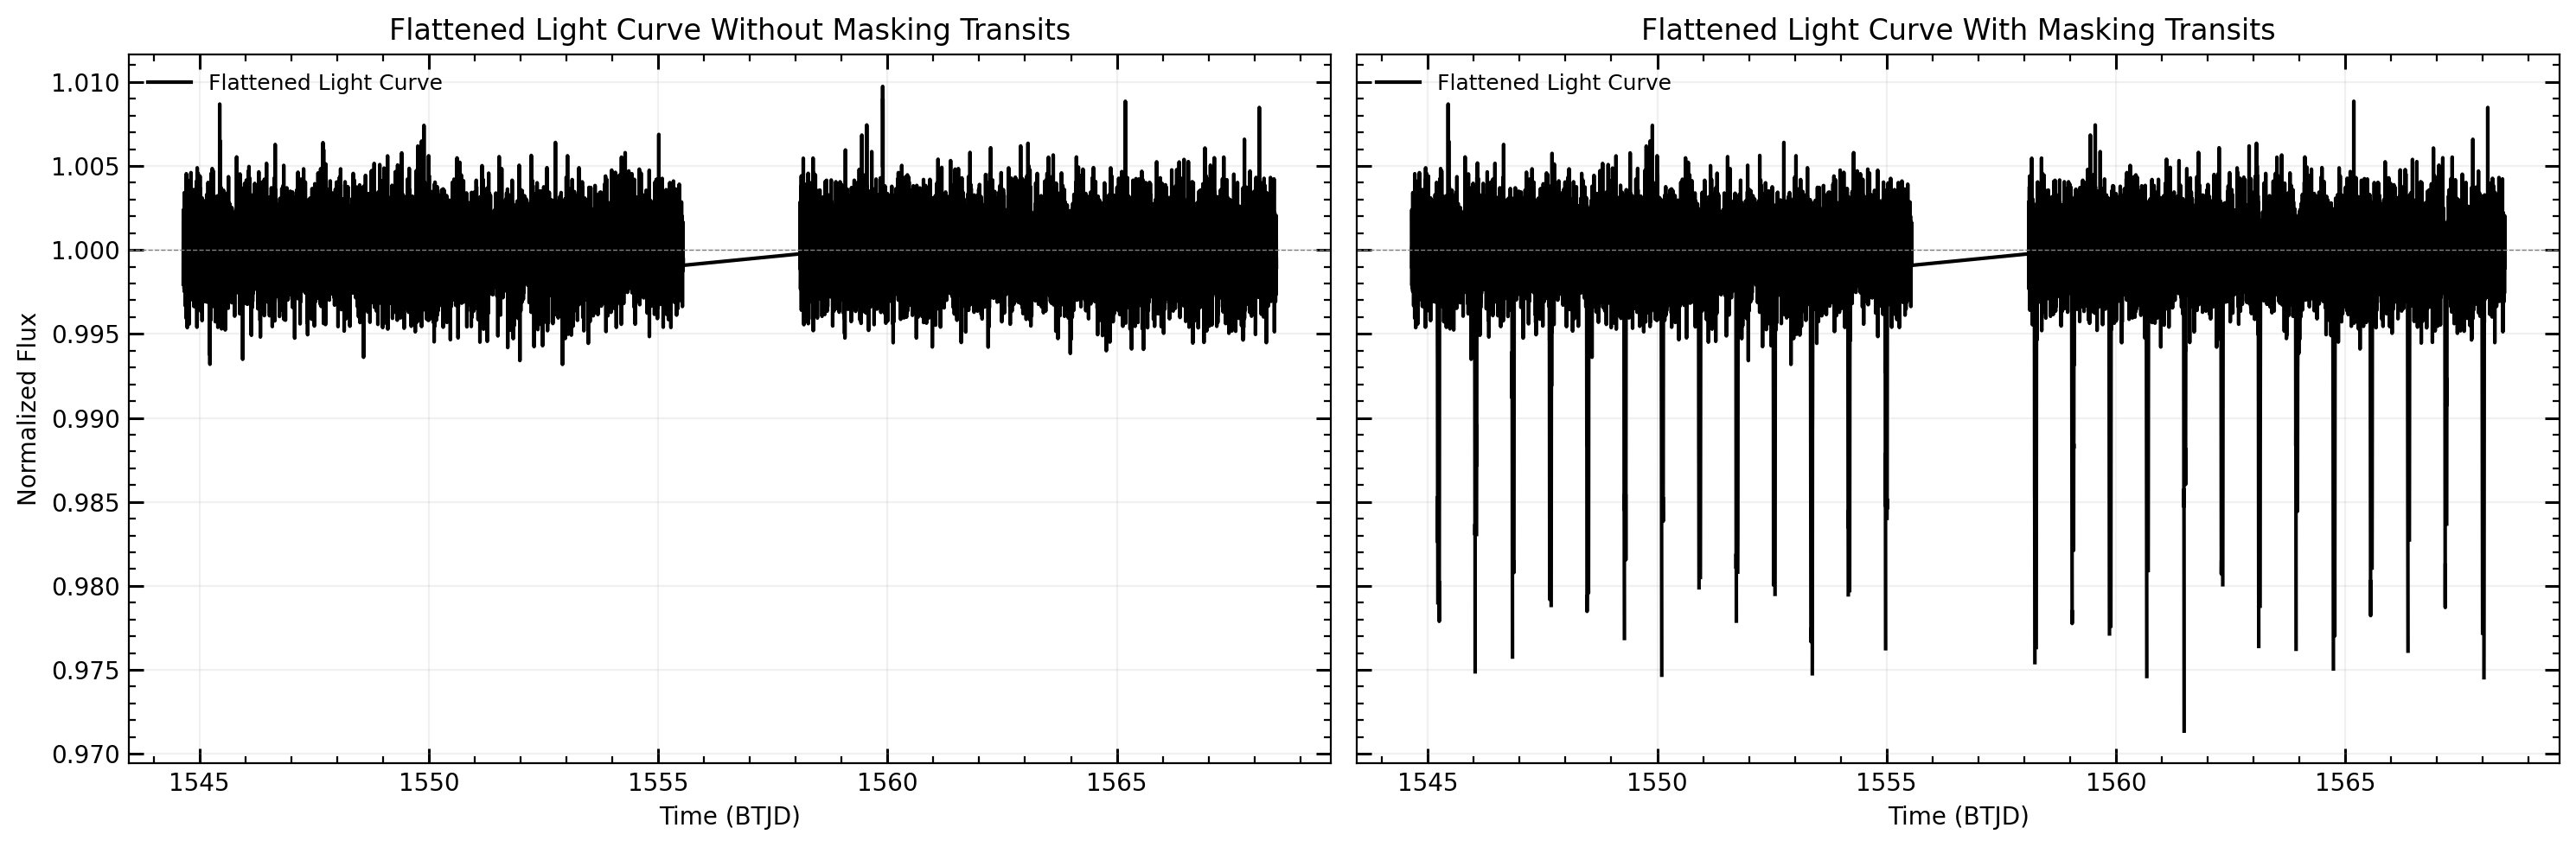

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, dpi=200, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: Raw data with computed stellar trend (No Mask)
ax[0].plot(time, flux, color='black', label = "Raw Light Curve")
ax[0].plot(time, trend_lc, color='red', label = "Stellar Trend")
ax[0].set_title('Light Curve with Computed Stellar Trend Without Masking Transits')
ax[0].set_ylabel('Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Right: Raw data with computed stellar trend (With Mask)
ax[1].plot(time, flux, color='black', label = "Raw Light Curve")
ax[1].plot(time, trend_lc_masked, color='cyan', label = "Stellar Trend")
ax[1].set_title('Light Curve with Computed Stellar Trend With Masking Transits')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="best")

plt.tight_layout()
plt.show()





fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, dpi=200, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: Flattened Result (No Mask)
ax[0].plot(time, flatten_lc, color='black', label = "Flattened Light Curve")
ax[0].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[0].set_title('Flattened Light Curve Without Masking Transits')
ax[0].set_ylabel('Normalized Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Right: Flattened Result (With Mask)
ax[1].plot(time, flatten_lc_masked, color='black', label = "Flattened Light Curve")
ax[1].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[1].set_title('Flattened Light Curve With Masking Transits')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

As one can tell by eye, masking out transits ensure the detrending does not partially fit out the transit itself, thus not biasing out depths. 

### ii) Comparing different window lengths

<b>Flatten parameters choices justifications for comparing window length:</b>

Window_length: According to wotan.readthedocs.com: "For the time-windowed sliders, the window should be 2-3 times longer than the transit duration". This makes sense since you want your window size to be as small as possible to remove stellar variability as effectively as possible without being too small where it will pick up on the transit signals. 

Method: Biweight because it's the default option and from the docs it's described as a robust sliding-window estimator and that is less sensitive to outliers and transit points. <b> I've experimented with 'cosine' and 'gp'. Ultimately, I stuck with the default for safety. </b>

I'll plot two different window lengths on the same plot: 3.0 * transit duration as per the docs, and the default 0.5 days window

In both cases, I am applying the transit mask

In [11]:
# flatten params
method = 'biweight' # Detrending algorithm 
return_trend = True # return stellar variation line as well as the flattend lc

# flatten lightcurve with half day window
flatten_halfday, trend_halfday = flatten(
    time, 
    flux, 
    window_length=0.5,       
    method=method,       
    return_trend=return_trend,
    mask=transit_mask,
)

# flatten lightcurve with 3 times duration window
flatten_3dur, trend_3dur = flatten(
    time, 
    flux, 
    window_length= 3.0 * duration_lit.to(u.day).value,       
    method=method,       
    return_trend=return_trend,
    mask=transit_mask,
)

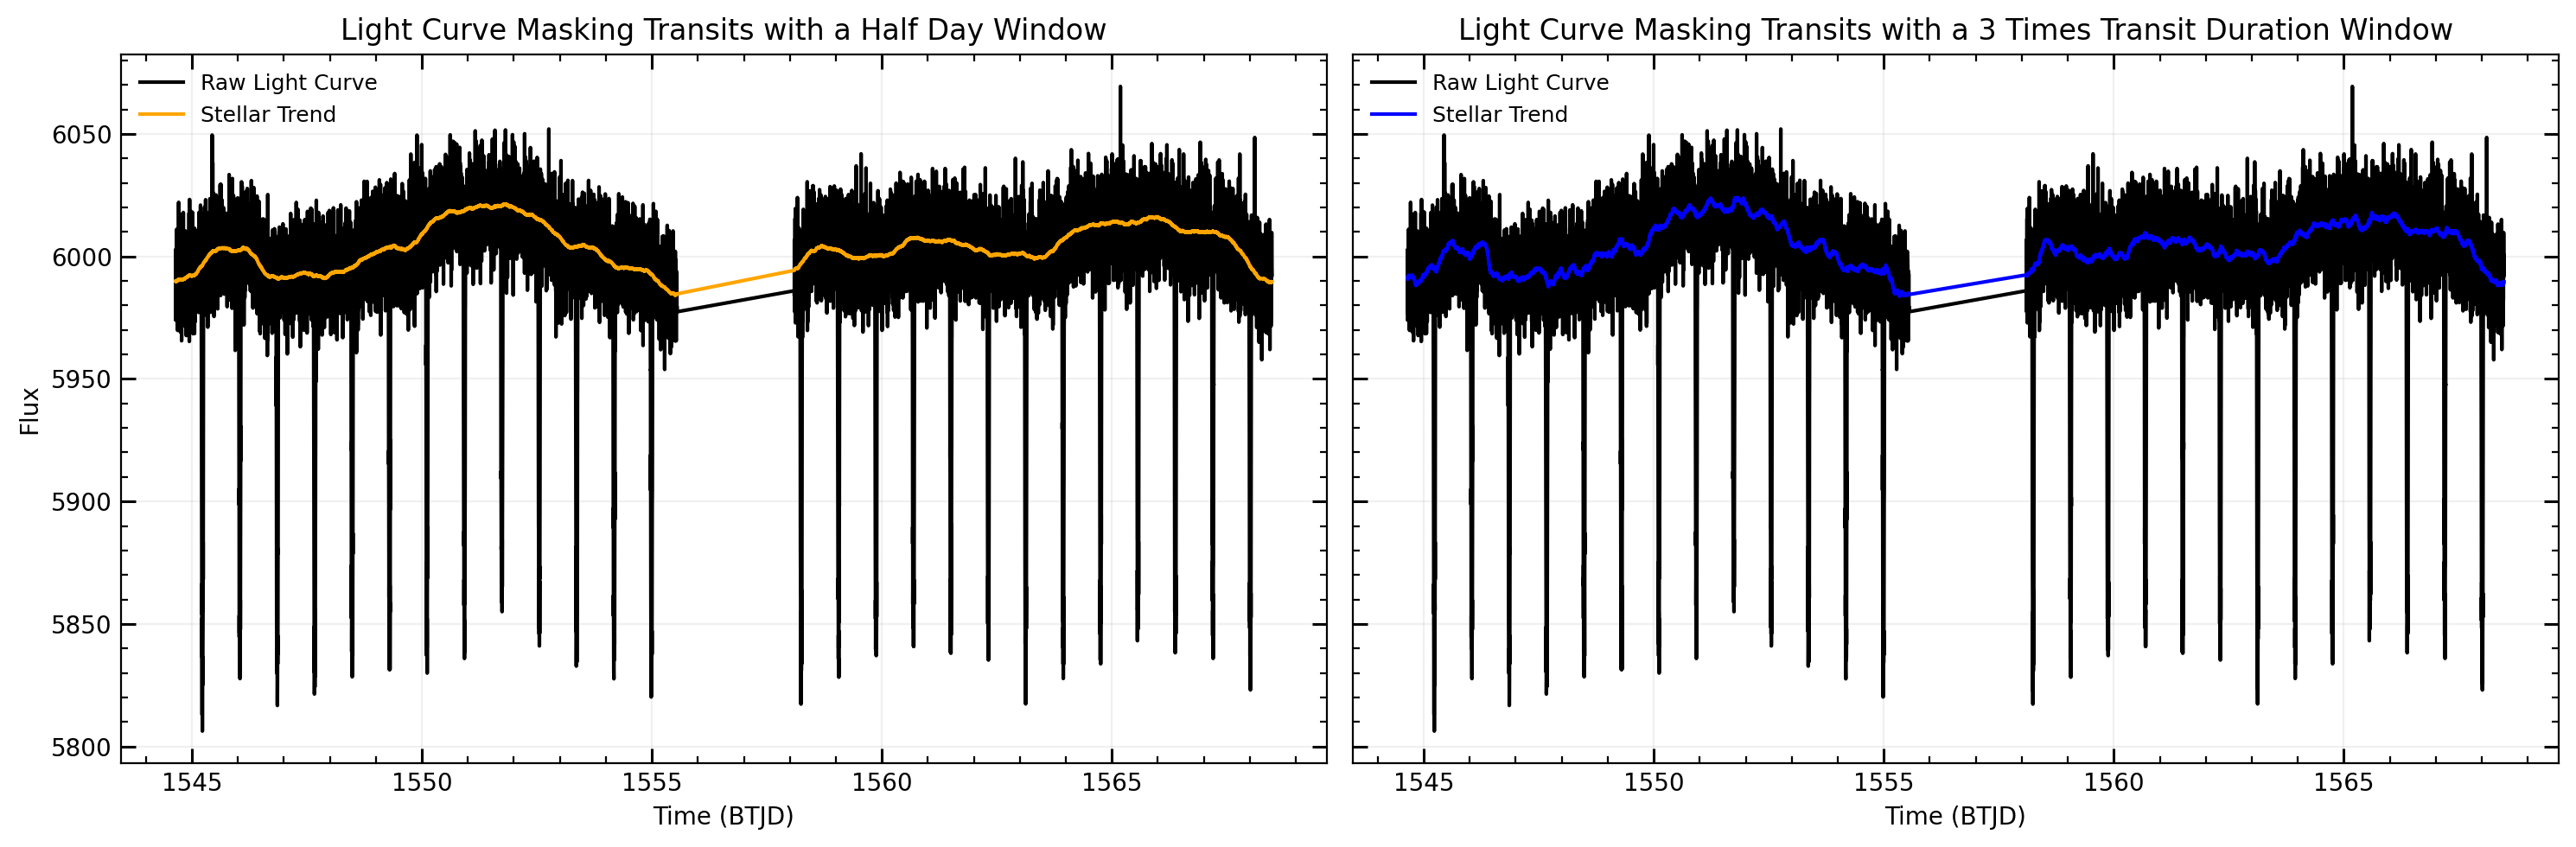

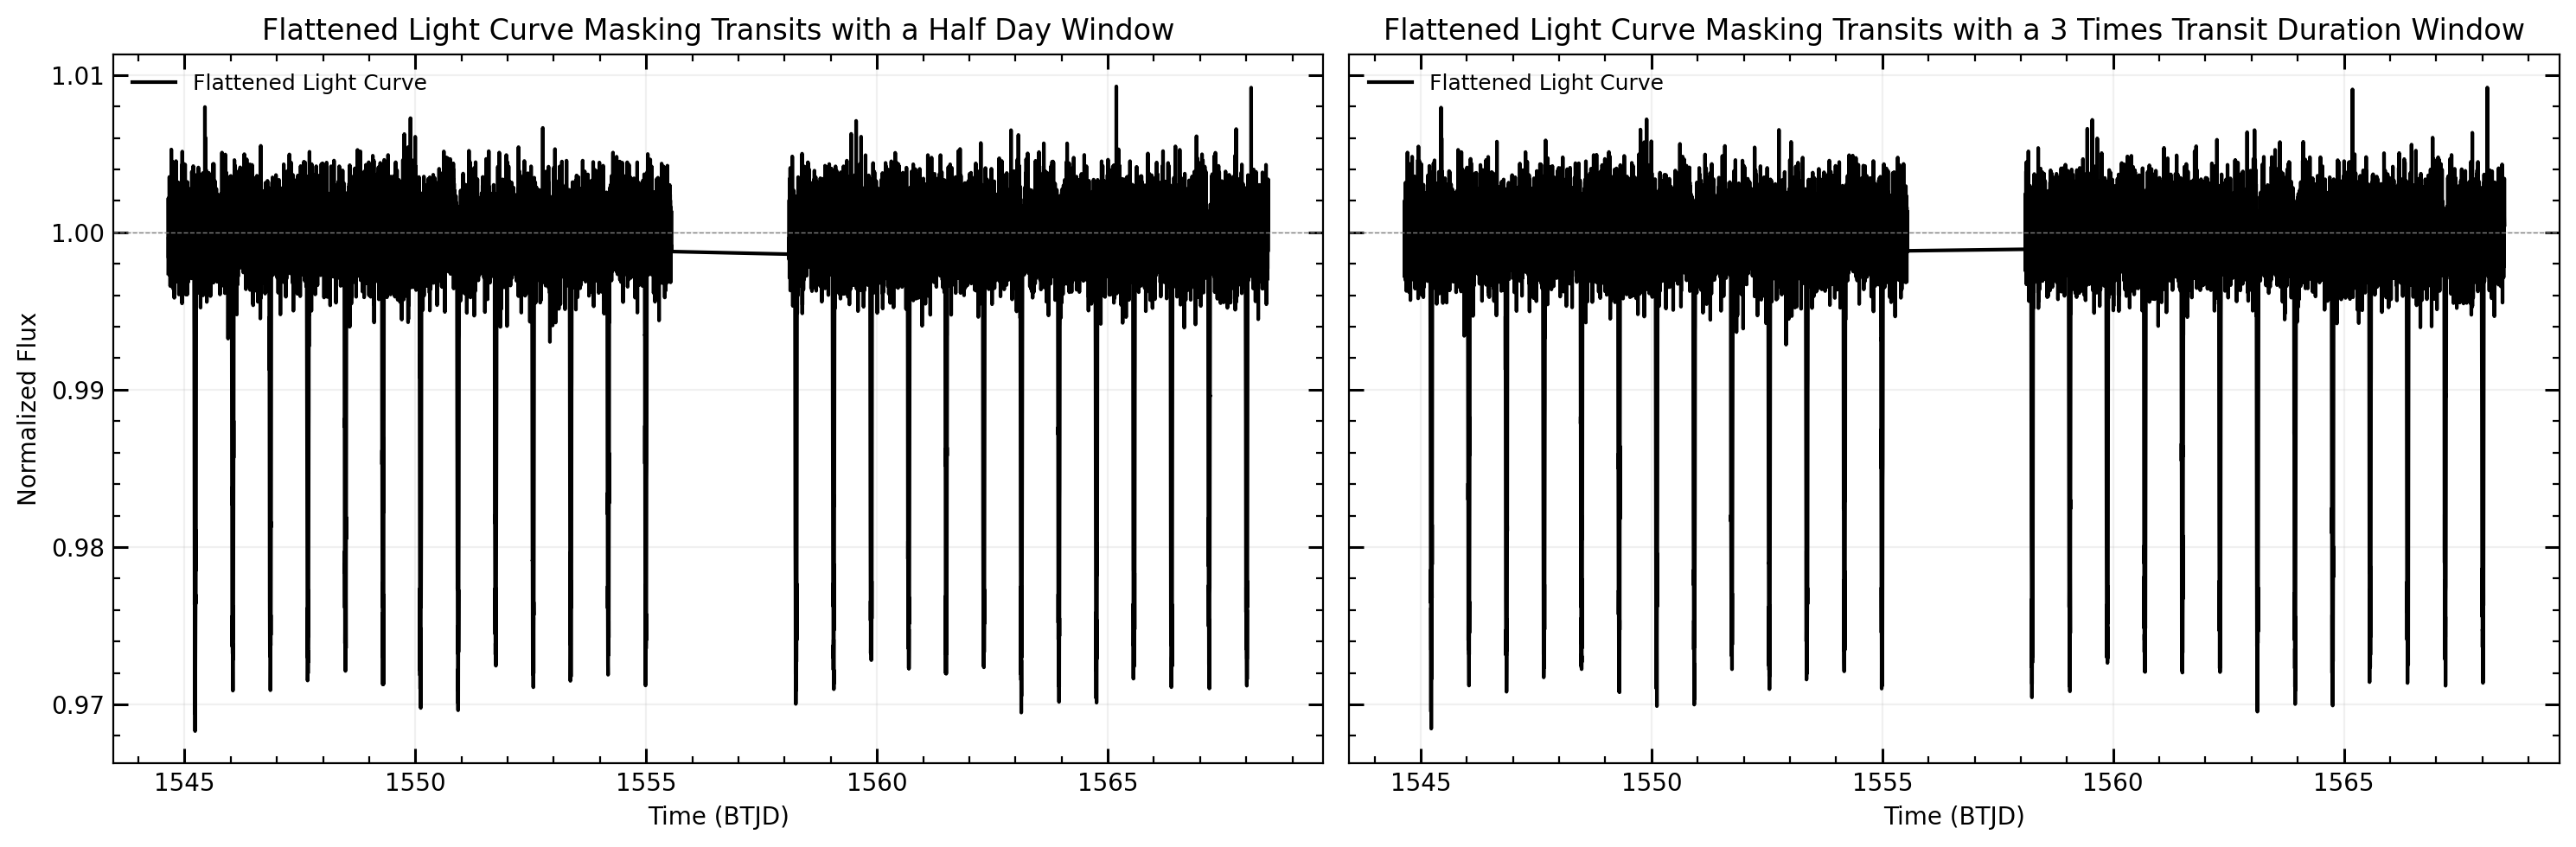

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, dpi=200, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: Half day window
ax[0].plot(time, flux, color='black', label = "Raw Light Curve")
ax[0].plot(time, trend_halfday, color='orange', label = "Stellar Trend")
ax[0].set_title('Light Curve Masking Transits with a Half Day Window')
ax[0].set_ylabel('Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Right: 3 times transit duration window
ax[1].plot(time, flux, color='black', label = "Raw Light Curve")
ax[1].plot(time, trend_3dur, color='blue', label = "Stellar Trend")
ax[1].set_title('Light Curve Masking Transits with a 3 Times Transit Duration Window')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="best")

plt.tight_layout()
plt.show()





fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharex=True, dpi=200, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: Half day window
ax[0].plot(time, flatten_halfday, color='black', label = "Flattened Light Curve")
ax[0].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[0].set_title('Flattened Light Curve Masking Transits with a Half Day Window')
ax[0].set_ylabel('Normalized Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Right: 3 times transit duration window
ax[1].plot(time, flatten_3dur, color='black', label = "Flattened Light Curve")
ax[1].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[1].set_title('Flattened Light Curve Masking Transits with a 3 Times Transit Duration Window')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

From this comparison, one can tell that with the smaller 3 times duration window, we can a higher resolution on the stellar trend, meaning that we are able to remove more stellar variability from the raw flux. This increases our SNR and is better for analysis. Again, it seems like the optimal approach is the make the window as small as possible without flattening through the transit. Since we are masking the transit, we have the luxury of making the window much smaller without running the risk of fitting out the transit itself. 

<b>Thus, I will be masking out the transits and using a 3 times duration window for the rest of my analysis. </b> 

### iii) Comparing different methods

I will compare using the default biweight method and the two recommended in the docs for when masking already discovered transit data while detrending: cosine and lowess. 

In [13]:
# flatten params
window_length = 3.0 * duration_lit.to(u.day).value # Filter length in units of time (e.g., days) 
return_trend = True # return stellar variation line as well as the flattend lc

# flatten lightcurve with biweight
flatten_biw, trend_biw = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method='biweight',       
    return_trend=return_trend,
)

# flatten lightcurve with cosine
flatten_cos, trend_cos = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method='cosine',       
    return_trend=return_trend,
    mask=transit_mask,
)

# flatten lightcurve with lowess
flatten_low, trend_low = flatten(
    time, 
    flux, 
    window_length=window_length,       
    method='lowess',       
    return_trend=return_trend,
    mask=transit_mask,
)

Converged.
Converged.


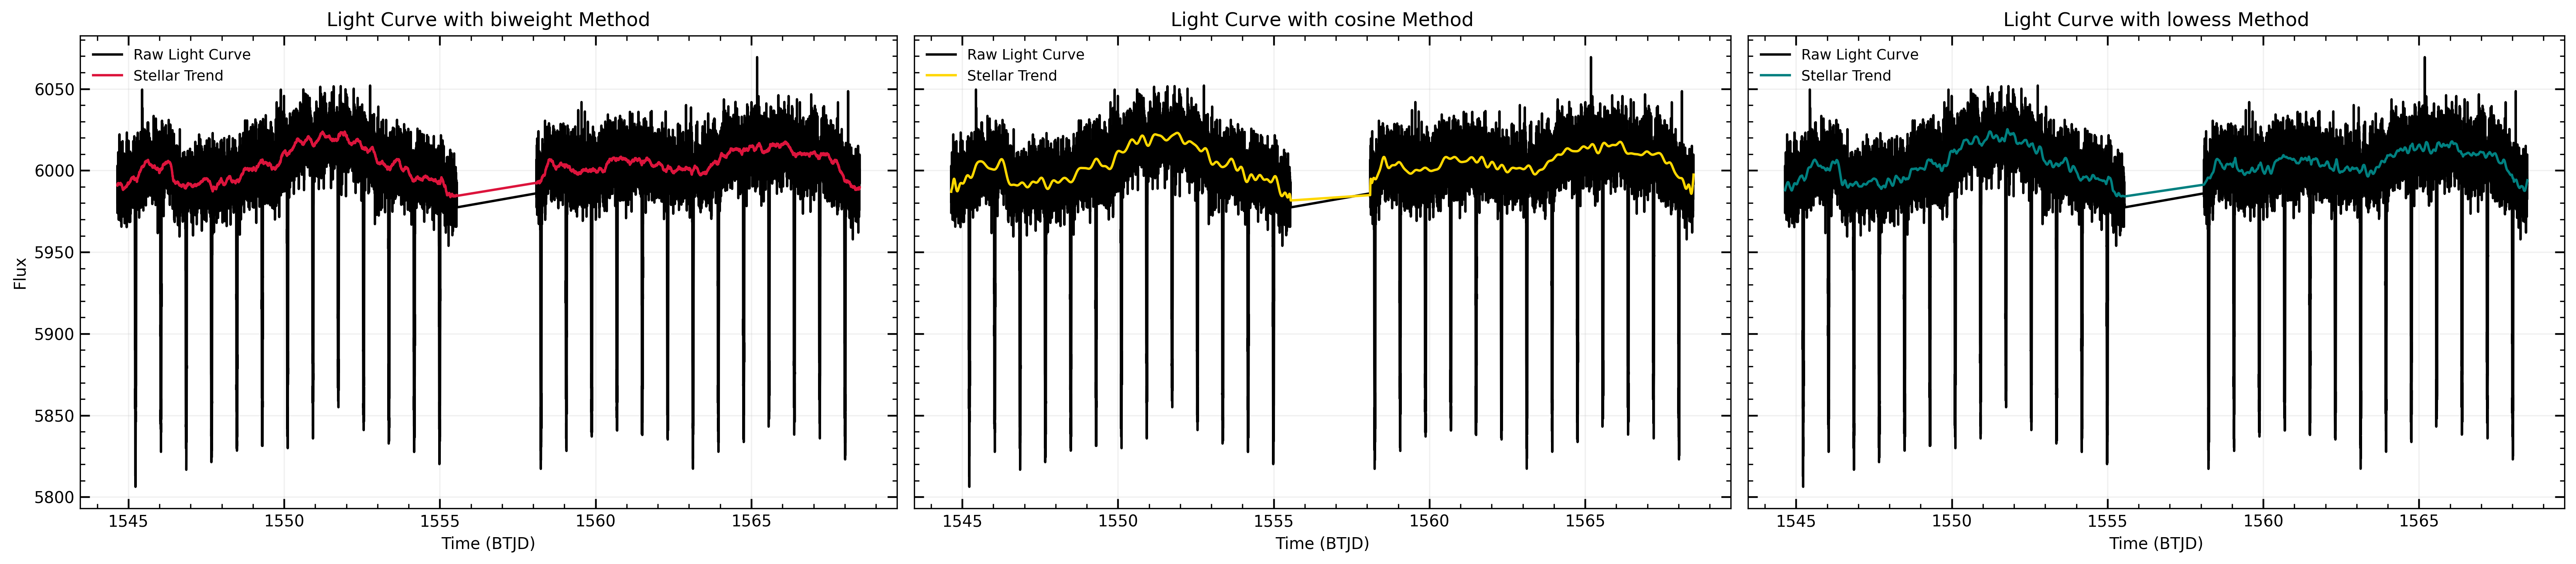

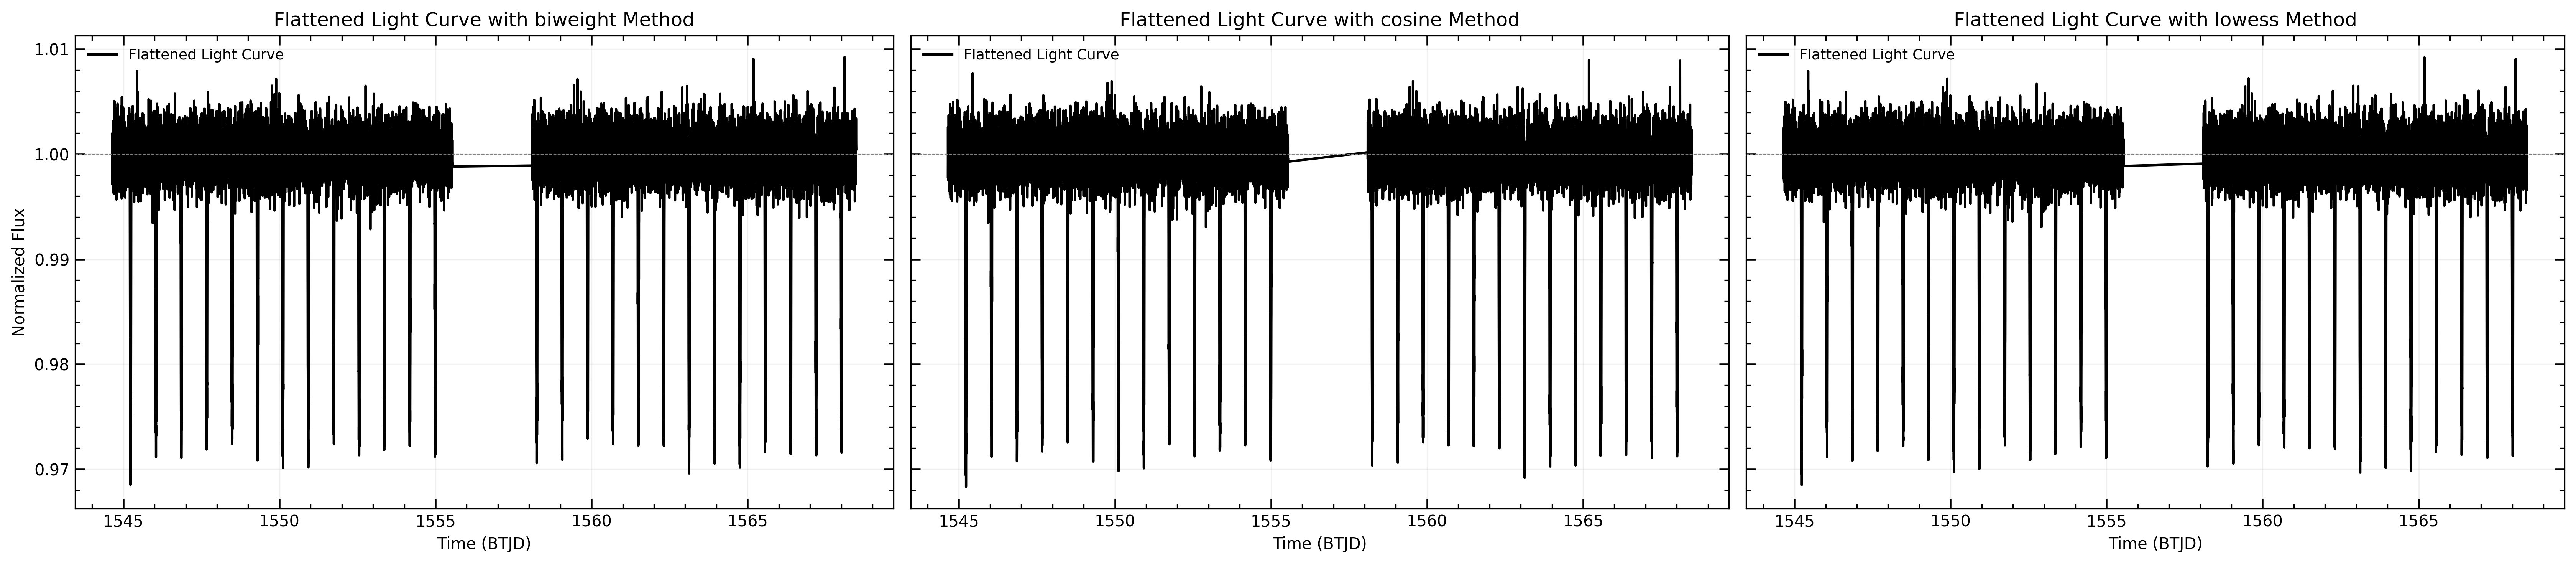

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(22.5, 5), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: biweight
ax[0].plot(time, flux, color='black', label = "Raw Light Curve")
ax[0].plot(time, trend_biw, color='crimson', label = "Stellar Trend")
ax[0].set_title('Light Curve with biweight Method')
ax[0].set_ylabel('Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Center: cosine
ax[1].plot(time, flux, color='black', label = "Raw Light Curve")
ax[1].plot(time, trend_cos, color='gold', label = "Stellar Trend")
ax[1].set_title('Light Curve with cosine Method')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="best")

# Right: lowess
ax[2].plot(time, flux, color='black', label = "Raw Light Curve")
ax[2].plot(time, trend_low, color='teal', label = "Stellar Trend")
ax[2].set_title('Light Curve with lowess Method')
ax[2].set_xlabel('Time (BTJD)')

ax[2].legend(frameon=False, fontsize=9, loc="best")

plt.tight_layout()
plt.show()





fig, ax = plt.subplots(1, 3, figsize=(22.5, 5), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
for a in ax:
    a.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
    a.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
    a.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    a.grid(True, which="major", alpha=0.18, lw=0.8)

# Left: biweight
ax[0].plot(time, flatten_biw, color='black', label = "Flattened Light Curve")
ax[0].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[0].set_title('Flattened Light Curve with biweight Method')
ax[0].set_ylabel('Normalized Flux')
ax[0].set_xlabel('Time (BTJD)')

ax[0].legend(frameon=False, fontsize=9, loc="best")

# Center: cosine
ax[1].plot(time, flatten_cos, color='black', label = "Flattened Light Curve")
ax[1].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[1].set_title('Flattened Light Curve with cosine Method')
ax[1].set_xlabel('Time (BTJD)')

ax[1].legend(frameon=False, fontsize=9, loc="upper left")

# Right: lowess
ax[2].plot(time, flatten_low, color='black', label = "Flattened Light Curve")
ax[2].axhline(1.0, color='gray', linestyle='--', alpha=1.0, lw=0.5)
ax[2].set_title('Flattened Light Curve with lowess Method')
ax[2].set_xlabel('Time (BTJD)')

ax[2].legend(frameon=False, fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

By eye these methods all seem somewhat similar, though the docs mention that if masking transits during detrending then one should use either 'cosine' or 'lowess'. I'll use 'lowess' since it seems it's closer to 'biweight' than 'cosine' is. 

## c) Write a function transit_model(params, time) that returns model flux using batman.TransitModel that assumes an eccentricity of 0 and a quadratic limb darkening model with the following free parameters: R_p/R_star, the planet radius in units of stellar radii, a/R_star, the semi-major axis in units of stellar radii, i , the inclination, t_0 , the mid-transit time, P, the orbital period, and u_1, u_2 the limb-darkening coefficients. Plot the model at the literature parameters from the NASA Exoplanet Archives over your flattened TESS sector lightcurve.

In [15]:
def transit_model(Rp, aR, i, t0, P , u1, u2, time):
    """
    Returns model flux using batman. Follows format from batman docs.

    Rp: Planet radius / Rstar (unitless)
    aR: semi-major axis / Rstar (unitless)
    i: inclination (deg)
    t0: mid-transit time (same units as 'time')
    P: orbital period (days)
    u1, u2: quadratic limb-darkening coefficients (unitless)
    time: array of time values
    """

    params = batman.TransitParams()
    params.t0 = t0
    params.per = P
    params.rp = Rp
    params.a = aR
    params.inc = i
    params.ecc = 0.0 # Assume zero eccentricity
    params.w = 90.0 # Assume 90 deg periastron
    params.u = [u1, u2] 
    params.limb_dark = "quadratic" # Assume quadratic limb-darkening

    m = batman.TransitModel(params, time)
    lc = m.light_curve(params)

    return lc

flattened light curve

In [16]:
# flattened lightcurve 
flatten_lc_optimal, trend_lc_optimal = flatten(
    time, 
    flux, 
    window_length= 3.0 * duration_lit.to(u.day).value,       
    method='lowess',       
    return_trend=True,
    mask=transit_mask,
)

batman model light curve, literature parameters from NASA exoplanet archive, limb-darkening parameters from: https://iopscience.iop.org/article/10.3847/1538-3881/ac1baf/pdf (Table A1)

In [32]:
batman_lc = transit_model(
    Rp=( (13.1118362739627 * u.earthRad)/(0.757649004459381 * u.solRad) ).decompose(), 
    aR=( (0.0142 * u.AU)/(0.757649004459381 * u.solRad) ).decompose(), 
    i=82.6, 
    t0=epoch_lit_BTJD, 
    P=period_lit.to(u.day).value, 
    u1=0.426, 
    u2=0.275, 
    time=time #BTJD
)

plotting over flattened light curve

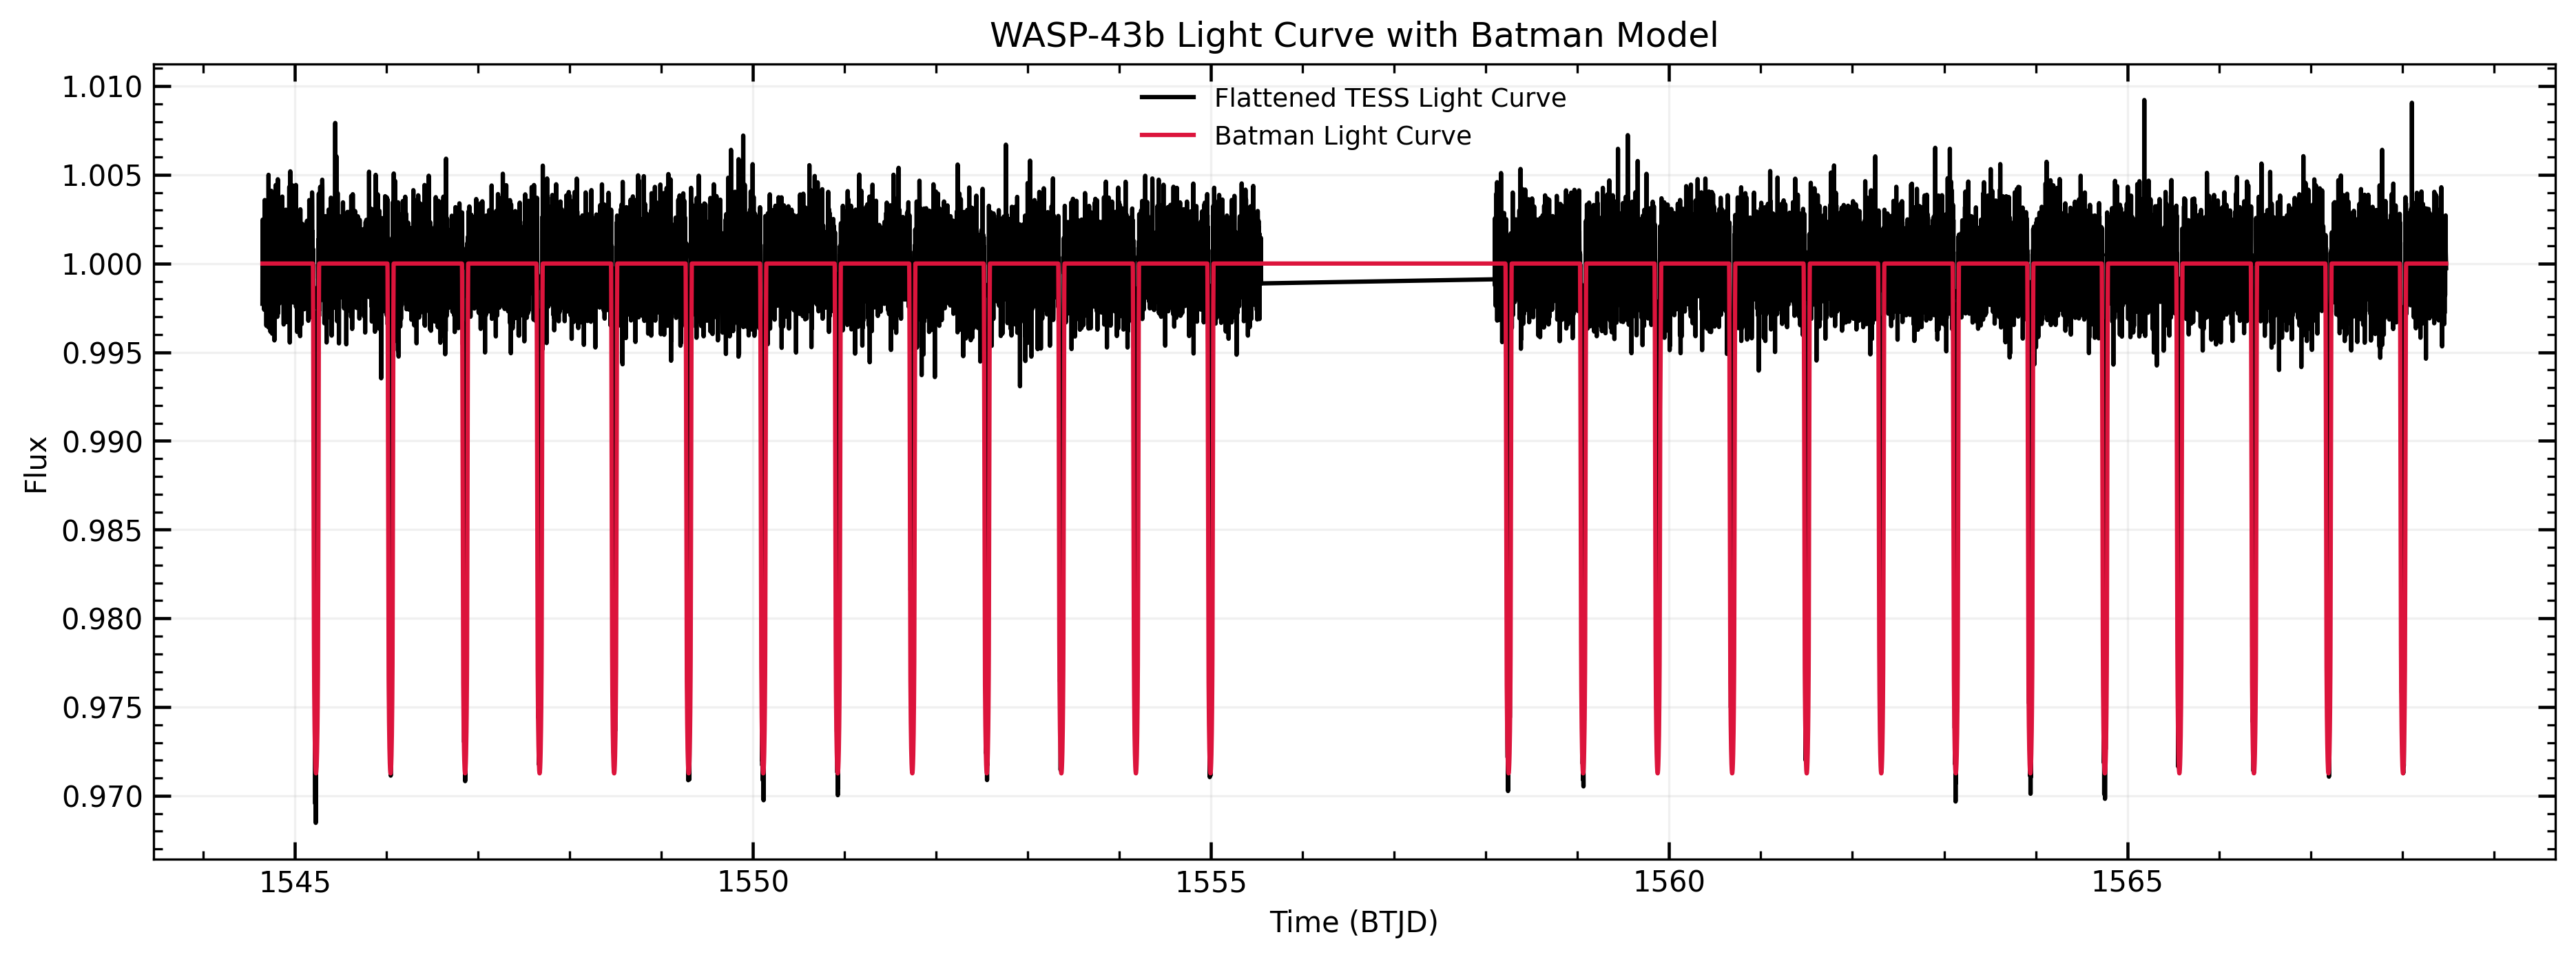

In [33]:
fig, ax = plt.subplots(figsize=(15, 5), sharex=True, dpi=300, sharey=True)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.plot(time, flatten_lc_optimal, color='black', label = "Flattened TESS Light Curve")
ax.plot(time, batman_lc, color='crimson', label = "Batman Light Curve")
ax.set_title('WASP-43b Light Curve with Batman Model')
ax.set_ylabel('Flux')
ax.set_xlabel('Time (BTJD)')

ax.legend(frameon=False, fontsize=9, loc="best")